In [218]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report, confusion_matrix
)

In [219]:
train=pd.read_csv('Titanic_train.csv')
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [220]:
test=pd.read_csv('Titanic_test.csv')

In [221]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [222]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [223]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [224]:
# Summary for categorical columns
train.describe(include=['O'])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


In [225]:
train.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

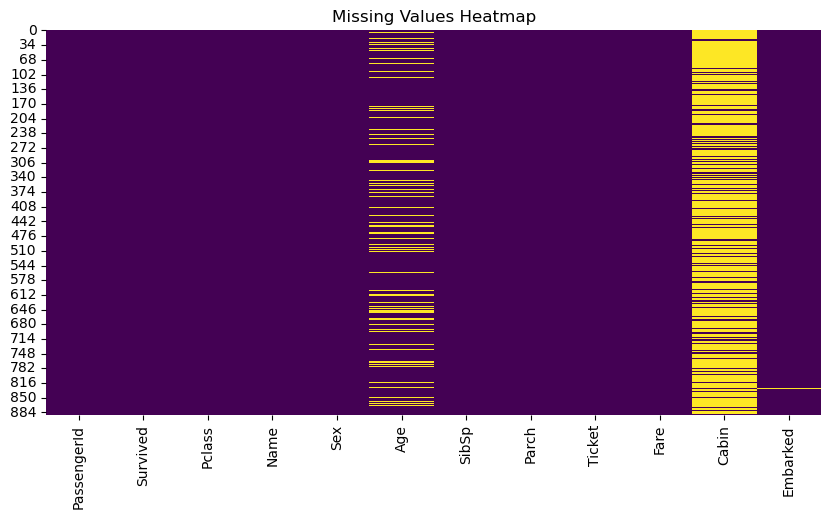

In [226]:
# Visualize missing values
plt.figure(figsize=(10,5))
sns.heatmap(train.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

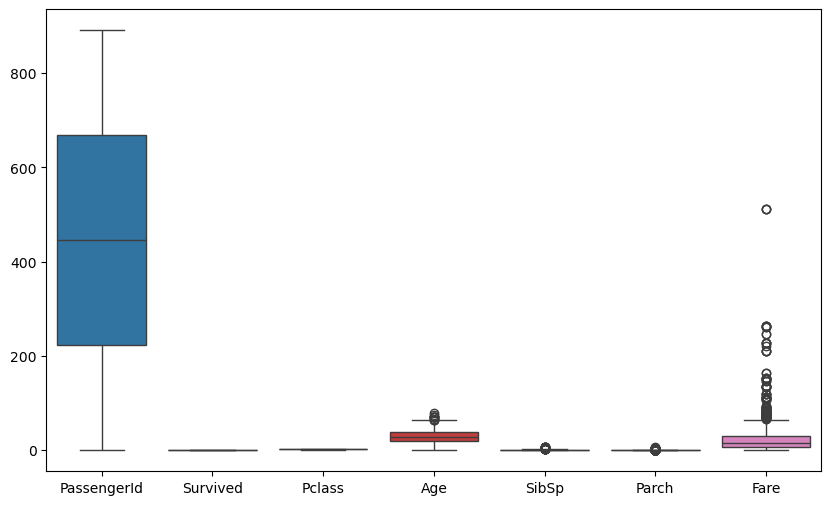

In [227]:
plt.figure(figsize=(10,6))
sns.boxplot(train)
plt.show()

In [228]:
# 🔹 Fill missing Age values with median
train['Age'] = train['Age'].fillna(train['Age'].median())

# 🔹 Fill missing Embarked values with mode (most frequent)
train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])

# 🔹 Create a new binary feature: HasCabin → 1 if Cabin info exists, else 0
train['HasCabin'] = train['Cabin'].notnull().astype(int)

# 🔹 Drop the original Cabin column (too many missing values)
train = train.drop(columns=['Cabin'])

In [229]:
# 🔹 Fill missing Age values with median
test['Age'] = test['Age'].fillna(test['Age'].median())

# 🔹 Fill missing Embarked values with mode (most frequent)
test['Embarked'] = test['Embarked'].fillna(test['Embarked'].mode()[0])

# 🔹 Create a new binary feature: HasCabin → 1 if Cabin info exists, else 0
test['HasCabin'] = test['Cabin'].notnull().astype(int)

# 🔹 Drop the original Cabin column (too many missing values)
test = test.drop(columns=['Cabin'])

In [230]:
train.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
HasCabin       0
dtype: int64

In [231]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,HasCabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


In [232]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,HasCabin
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S,0
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q,0
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S,0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S,0


In [233]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
 11  HasCabin     891 non-null    int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 83.7+ KB


In [234]:
corr=train.corr(numeric_only=True)
corr

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,HasCabin
PassengerId,1.000000,-0.005007,-0.035144,0.034212,-0.057527,-0.001652,0.012658,0.019919
Survived,-0.005007,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307,0.316912
Pclass,-0.035144,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500,-0.725541
Age,0.034212,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688,0.240314
SibSp,-0.057527,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651,-0.040460
Parch,-0.001652,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225,0.036987
Fare,0.012658,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000,0.482075
HasCabin,0.019919,0.316912,-0.725541,0.240314,-0.040460,0.036987,0.482075,1.000000


In [235]:
train = train.drop(columns=['Ticket'])

In [236]:
test = test.drop(columns=['Ticket'])

In [237]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,HasCabin
0,892,3,"Kelly, Mr. James",male,34.5,0,0,7.8292,Q,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,7.0000,S,0
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,9.6875,Q,0
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,8.6625,S,0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,12.2875,S,0


In [238]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,HasCabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,0


In [239]:
train1=train.copy()

In [240]:
test1=test.copy()

In [241]:
# 🔹 Convert 'Sex' to numeric: male → 0, female → 1
train1['Sex'] = train1['Sex'].map({'male': 0, 'female': 1})

# 🔹 Convert 'Embarked' using one-hot encoding (since it has more than 2 categories)
train1 = pd.get_dummies(train1, columns=['Embarked'], drop_first=True)

In [242]:
# 🔹 Convert 'Sex' to numeric: male → 0, female → 1
test1['Sex'] = test1['Sex'].map({'male': 0, 'female': 1})

# 🔹 Convert 'Embarked' using one-hot encoding (since it has more than 2 categories)
test1 = pd.get_dummies(test1, columns=['Embarked'], drop_first=True)

In [243]:
train1.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,HasCabin,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,7.2500,0,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,71.2833,1,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,7.9250,0,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,53.1000,1,False,True
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,8.0500,0,False,True


In [244]:
test1.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Fare,HasCabin,Embarked_Q,Embarked_S
0,892,3,"Kelly, Mr. James",0,34.5,0,0,7.8292,0,True,False
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,7.0000,0,False,True
2,894,2,"Myles, Mr. Thomas Francis",0,62.0,0,0,9.6875,0,True,False
3,895,3,"Wirz, Mr. Albert",0,27.0,0,0,8.6625,0,False,True
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,12.2875,0,False,True


In [245]:
# 🔹 Extract title from Name (e.g., Mr, Mrs, Miss, Master, etc.)
train1['Title'] = train1['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# 🔹 Combine rare titles into a single category 'Other'
rare_titles = ['Dr', 'Rev', 'Col', 'Major', 'Mlle', 'Countess', 'Ms', 
               'Lady', 'Jonkheer', 'Don', 'Dona', 'Mme', 'Capt', 'Sir']
train1['Title'] = train1['Title'].replace(rare_titles, 'Other')

# 🔹 One-hot encode the Title column to convert it into numeric features
train1 = pd.get_dummies(train1, columns=['Title'], drop_first=True)

# 🔹 Drop the original Name column since it’s no longer needed
train1 = train1.drop(columns=['Name'])


In [246]:
# 🔹 Extract title from Name (e.g., Mr, Mrs, Miss, Master, etc.)
test1['Title'] = test1['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# 🔹 Combine rare titles into a single category 'Other'
rare_titles = ['Dr', 'Rev', 'Col', 'Major', 'Mlle', 'Countess', 'Ms', 
               'Lady', 'Jonkheer', 'Don', 'Dona', 'Mme', 'Capt', 'Sir']
test1['Title'] = test1['Title'].replace(rare_titles, 'Other')

# 🔹 One-hot encode the Title column to convert it into numeric features
test1 = pd.get_dummies(test1, columns=['Title'], drop_first=True)

# 🔹 Drop the original Name column since it’s no longer needed
test1 = test1.drop(columns=['Name'])


In [247]:
train1.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,HasCabin,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Other
0,1,0,3,0,22.0,1,0,7.2500,0,False,True,False,True,False,False
1,2,1,1,1,38.0,1,0,71.2833,1,False,False,False,False,True,False
2,3,1,3,1,26.0,0,0,7.9250,0,False,True,True,False,False,False
3,4,1,1,1,35.0,1,0,53.1000,1,False,True,False,False,True,False
4,5,0,3,0,35.0,0,0,8.0500,0,False,True,False,True,False,False


In [248]:
test1.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,HasCabin,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Other
0,892,3,0,34.5,0,0,7.8292,0,True,False,False,True,False,False
1,893,3,1,47.0,1,0,7.0000,0,False,True,False,False,True,False
2,894,2,0,62.0,0,0,9.6875,0,True,False,False,True,False,False
3,895,3,0,27.0,0,0,8.6625,0,False,True,False,True,False,False
4,896,3,1,22.0,1,1,12.2875,0,False,True,False,False,True,False


In [249]:
train1.duplicated().sum()

np.int64(0)

In [250]:
corr=train1.corr(numeric_only=True)
corr

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,HasCabin,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Other
PassengerId,1.000000,-0.005007,-0.035144,-0.042939,0.034212,-0.057527,-0.001652,0.012658,0.019919,-0.033606,0.022204,-0.073110,0.038850,0.011245,0.068907
Survived,-0.005007,1.000000,-0.338481,0.543351,-0.064910,-0.035322,0.081629,0.257307,0.316912,0.003650,-0.149683,0.327093,-0.549199,0.339040,0.022030
Pclass,-0.035144,-0.338481,1.000000,-0.131900,-0.339898,0.083081,0.018443,-0.549500,-0.725541,0.221009,0.074053,-0.000576,0.142698,-0.149209,-0.206333
Sex,-0.042939,0.543351,-0.131900,1.000000,-0.081163,0.114631,0.245489,0.182333,0.140391,0.074115,-0.119224,0.686808,-0.867334,0.547600,-0.034471
Age,0.034212,-0.064910,-0.339898,-0.081163,1.000000,-0.233296,-0.172482,0.096688,0.240314,-0.031415,-0.006729,-0.247483,0.180808,0.169578,0.169684
SibSp,-0.057527,-0.035322,0.083081,0.114631,-0.233296,1.000000,0.414838,0.159651,-0.040460,-0.026354,0.068734,0.087932,-0.250489,0.063407,-0.036364
Parch,-0.001652,0.081629,0.018443,0.245489,-0.172482,0.414838,1.000000,0.216225,0.036987,-0.081228,0.060814,0.105567,-0.333905,0.225852,-0.067480
Fare,0.012658,0.257307,-0.549500,0.182333,0.096688,0.159651,0.216225,1.000000,0.482075,-0.117216,-0.162184,0.118271,-0.183766,0.105203,0.024585
HasCabin,0.019919,0.316912,-0.725541,0.140391,0.240314,-0.040460,0.036987,0.482075,1.000000,-0.129572,-0.101139,0.035314,-0.137319,0.118300,0.106246
Embarked_Q,-0.033606,0.003650,0.221009,0.074115,-0.031415,-0.026354,-0.081228,-0.117216,-0.129572,1.000000,-0.499421,0.171117,-0.078338,-0.089739,-0.007767


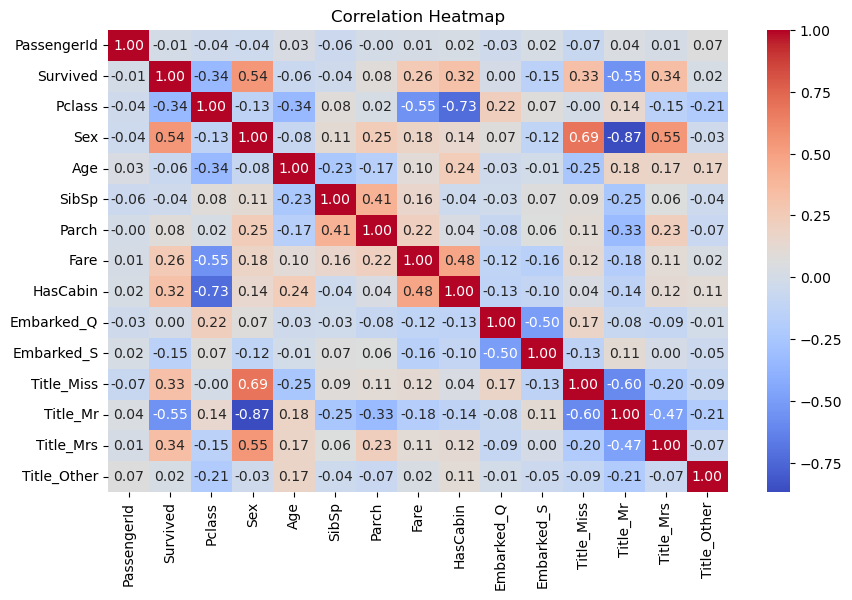

In [251]:
# Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(train1.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [252]:
# Find pairs of features with correlation > 0.7 or < -0.7
strong_corr = corr[(corr > 0.7) | (corr < -0.7)]
print("Strong correlations:\n", strong_corr)

Strong correlations:
              PassengerId  Survived    Pclass       Sex  Age  SibSp  Parch  \
PassengerId          1.0       NaN       NaN       NaN  NaN    NaN    NaN   
Survived             NaN       1.0       NaN       NaN  NaN    NaN    NaN   
Pclass               NaN       NaN  1.000000       NaN  NaN    NaN    NaN   
Sex                  NaN       NaN       NaN  1.000000  NaN    NaN    NaN   
Age                  NaN       NaN       NaN       NaN  1.0    NaN    NaN   
SibSp                NaN       NaN       NaN       NaN  NaN    1.0    NaN   
Parch                NaN       NaN       NaN       NaN  NaN    NaN    1.0   
Fare                 NaN       NaN       NaN       NaN  NaN    NaN    NaN   
HasCabin             NaN       NaN -0.725541       NaN  NaN    NaN    NaN   
Embarked_Q           NaN       NaN       NaN       NaN  NaN    NaN    NaN   
Embarked_S           NaN       NaN       NaN       NaN  NaN    NaN    NaN   
Title_Miss           NaN       NaN       NaN       NaN

In [253]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


X = train1[['Pclass', 'HasCabin']]  # focus on the pair
vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)


    Feature       VIF
0    Pclass  1.057459
1  HasCabin  1.057459


In [254]:
# Hence no Correlation

In [255]:
train1.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,HasCabin,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Other
0,1,0,3,0,22.0,1,0,7.2500,0,False,True,False,True,False,False
1,2,1,1,1,38.0,1,0,71.2833,1,False,False,False,False,True,False
2,3,1,3,1,26.0,0,0,7.9250,0,False,True,True,False,False,False
3,4,1,1,1,35.0,1,0,53.1000,1,False,True,False,False,True,False
4,5,0,3,0,35.0,0,0,8.0500,0,False,True,False,True,False,False


In [256]:
x_train=train1.iloc[:,2:]
y_train=train1['Survived']

In [257]:
x_test=test1.iloc[:,1:]


In [258]:
# --- Ensure columns in test match training ---
x_test = x_test.reindex(columns=x_train.columns, fill_value=0)

In [259]:
num_imputer = SimpleImputer(strategy='mean')

In [260]:
x_train = pd.DataFrame(num_imputer.fit_transform(x_train), columns=x_train.columns)
x_test = pd.DataFrame(num_imputer.transform(x_test), columns=x_test.columns)

In [261]:
scaler = StandardScaler()

In [262]:
# Fit on training data and transform both train and test
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

In [263]:
X_train,x_test,y_train,y_test=train_test_split(X_train_scaled,y_train,test_size=0.2)
X_train.shape,x_test.shape,y_train.shape,y_test.shape

((712, 13), (179, 13), (712,), (179,))

In [264]:
# Initialize Logistic Regression model
model = LogisticRegression(class_weight='balanced',max_iter=1000, random_state=42)

# Fit the model on training data
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [265]:
def evaluate_cif(y,yhat):
    cm=confusion_matrix(y,yhat)
    plt.figure(figsize=(3,3))
    sns.heatmap(cm,cbar=False,annot=True,fmt='d')
    plt.show()
    print(classification_report(y_train,yhat_train))
    plt.figure(figsize=(3,3))
    plt.title('AUC_ROC Curve')
    plt.xlabel('False positive rate')
    plt.ylabel('True positive rate')
    fpr,tpr,thresh=roc_curve(y,yhat)
    plt.plot(fpr,tpr)
    plt.plot([0,1],[0,1],linestyle='dashed')
    plt.show()
    print(roc_auc_score(y_train,yhat_train))

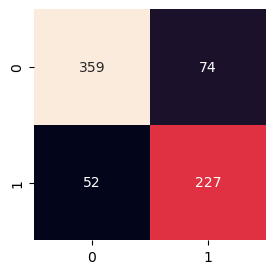

In [266]:
yhat_train=model.predict(X_train)
cm=confusion_matrix(y_train,yhat_train)
plt.figure(figsize=(3,3))
sns.heatmap(cm,cbar=False,annot=True,fmt='d')
plt.show()

In [267]:
print(classification_report(y_train,yhat_train))

              precision    recall  f1-score   support

           0       0.87      0.83      0.85       433
           1       0.75      0.81      0.78       279

    accuracy                           0.82       712
   macro avg       0.81      0.82      0.82       712
weighted avg       0.83      0.82      0.82       712



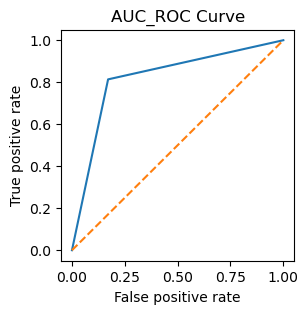

In [268]:
plt.figure(figsize=(3,3))
plt.title('AUC_ROC Curve')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
fpr,tpr,thresh=roc_curve(y_train,yhat_train)
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],linestyle='dashed')
plt.show()

In [269]:
print(roc_auc_score(y_train,yhat_train))

0.8213596894219706


In [270]:
yhat_test=model.predict(x_test)

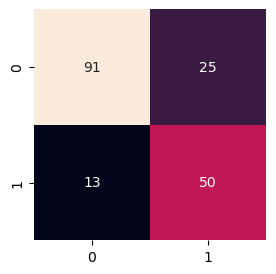

              precision    recall  f1-score   support

           0       0.87      0.83      0.85       433
           1       0.75      0.81      0.78       279

    accuracy                           0.82       712
   macro avg       0.81      0.82      0.82       712
weighted avg       0.83      0.82      0.82       712



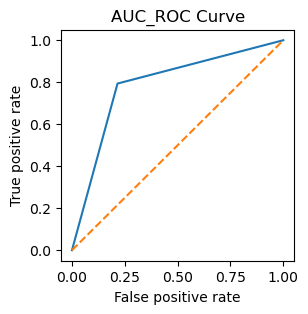

0.8213596894219706


In [271]:
evaluate_cif(y_test,yhat_test)

In [272]:
y_train_pred = model.predict(x_train)

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [273]:

y_test_pred = model.predict(X_test_scaled)


In [274]:
y_test_pred

array([0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [275]:
# Reattach correct feature names manually
feature_names = train1.drop(columns=['Survived', 'PassengerId']).columns

coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_[0]
})

# Compute odds ratios
coefficients['Odds_Ratio'] = np.exp(coefficients['Coefficient'])
coefficients['AbsValue'] = coefficients['Coefficient'].abs()

# Sort by importance
coefficients = coefficients.sort_values(by='AbsValue', ascending=False)

# Display result
print(coefficients[['Feature', 'Coefficient', 'Odds_Ratio']])

        Feature  Coefficient  Odds_Ratio
10     Title_Mr    -1.592290    0.203459
9    Title_Miss    -0.708728    0.492270
1           Sex     0.699333    2.012411
0        Pclass    -0.662546    0.515537
3         SibSp    -0.588497    0.555161
12  Title_Other    -0.499773    0.606668
2           Age    -0.383099    0.681745
6      HasCabin     0.376725    1.457503
4         Parch    -0.294466    0.744929
11    Title_Mrs    -0.289227    0.748842
8    Embarked_S    -0.157836    0.853990
5          Fare     0.120228    1.127754
7    Embarked_Q    -0.003188    0.996817


######  The logistic regression coefficients represent the effect of each feature on the survival probability. A positive coefficient increases the odds of survival, while a negative one decreases it. For example, features like Sex (female), HasCabin, and Fare have positive effects, indicating higher survival chances, whereas Pclass, SibSp, and Title_Mr have negative coefficients, showing lower survival likelihood.

###### The most significant predictors of survival are Pclass, Sex, SibSp, and Age, as they have higher coefficient magnitudes. This means passenger class, gender, and family size strongly influence survival probability, while other variables like Embarked or Fare have weaker impacts.

In [276]:
import pickle

# Save the model
with open("titanic_model.pkl", "wb") as file:
    pickle.dump(model, file)


In [277]:
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

In [278]:
# Just to verify scaling effect
sample = pd.DataFrame({
    'Pclass': [1],
    'Sex': [1],  # female
    'Age': [25],
    'SibSp': [0],
    'Parch': [0],
    'Fare': [100],
    'HasCabin': [1],
    'Embarked_Q': [0],
    'Embarked_S': [0],
    'Title_Miss': [1],
    'Title_Mr': [0],
    'Title_Mrs': [0],
    'Title_Other': [0]
})
sample_scaled = scaler.transform(sample)
print(model.predict_proba(sample_scaled))


[[0.01601663 0.98398337]]


In [279]:
sample_scaled = scaler.transform(sample)
print(model.predict_proba(sample_scaled))


[[0.01601663 0.98398337]]


###### Precision measures how many of the predicted positive cases were actually correct (TP / (TP + FP)), while recall measures how many of the actual positive cases were correctly identified (TP / (TP + FN)). Precision focuses on the accuracy of positive predictions, whereas recall focuses on the completeness of detecting all positives. 
###### Cross-validation is a method to evaluate how well a model generalizes by splitting data into several parts (folds), training on some, and validating on others. It provides a more reliable performance estimate, prevents overfitting, and ensures consistent model accuracy across different data splits.